In [1]:
import pandas as pd

In [2]:
import sys
sys.path.append('/home/evlasova/mirpy')

In [3]:
import sys
sys.path.append('/home/evlasova/mirpy')
from mir.common.clonotype_dataset import ClonotypeDataset
from mir.common.clonotype import ClonotypeAA

In [4]:
def get_sample_info(sample_name):
    data_path = f'/projects/immunestatus/rheum/tcrempnet_b27pos_new'
    summary = pd.read_csv(f'{data_path}/{sample_name}_summary_tcrempnet.tsv', sep='\t')
    # summary = summary[summary.cluster_size > 4]
    c0 = 857708
    c15 = len(pd.read_csv(
        f'/projects/immunestatus/rheum/airr_format/{sample_name}.tsv', sep='\t'))
    print(f'''
    sample: {sample_name}
    clusters: {len(summary)}
    overall from background: {c0}
    overall from sample: {c15}
    ''')
    return summary, c0, c15

In [5]:
as_seqs = [
    'CASSVGLFSTDTQYF',
    'CASSVGLYSTDTQYF',
    'CASSAGLFSTDTQYF',
    'CASSAGLYSTDTQYF',
    'CASSLGLFSTDTQYF',
    'CASSLGLYSTDTQYF',
    'CASSPGLFSTDTQYF',
    'CASSPGLYSTDTQYF'
]
as_clonotypes = [ClonotypeAA(cdr3aa=x) for x in as_seqs]

In [6]:
as_clonotypes = [ClonotypeAA(cdr3aa=x) for x in as_seqs]
vdjdb = ClonotypeDataset(as_clonotypes)

In [7]:
vdjdb

A dataset of 8 clonotypes and 1 clusters

In [8]:
vdjdb.get_matching_clonotypes('CASSLAPGATNEQLFF')

set()

In [9]:
def get_clonotypes(sample_name):
    data_path = f'/projects/immunestatus/rheum/tcrempnet_b27pos_new'
    df = pd.read_csv(f'{data_path}/{sample_name}_enriched_clonotypes_tcremp.tsv', sep='\t')
    return df

In [10]:
def has_vdjdb_match(x, threshold=1):
    return len(vdjdb.get_matching_clonotypes(x, threshold=threshold))

def get_cluster_matches_vdjdb(df, cluster_id):
    df = df[df.cluster_id == cluster_id]
    matches = df.cdr3aa_beta.apply(has_vdjdb_match)
    return sum(matches) > 0

In [11]:
metadata = pd.read_csv("/projects/immunestatus/rheum/airr_format/metadata.tsv", sep='\t')

In [12]:
metadata

,donor_id,disease_status,b27,proj,sample_type,time_point,sample_name,fraction
0,Koc,hd,pos,GCSF,PBMC,normal blood,Koc,NaN
1,Make,hd,pos,ch45,CD45RAdepleted PBMC,after G-CSFstim,Make,NaN
2,p144852,hd,pos,ch45-2,PBMC,after G-CSFstim,p144852,NaN
3,p1004,hd,pos,child_Leu,PBMC,after G-CSFstim,p1004,NaN
4,p112635,hd,pos,ch45-2,PBMC,after G-CSFstim,p112635,NaN
...,...,...,...,...,...,...,...,...
63,Vol,as,pos,NaN,PBMC,NaN,as_Vol_PB_F,bulk
64,ZN,hd,pos,NaN,PBMC,NaN,hd_ZN_PB_F,bulk
65,Zakh,as,pos,NaN,PBMC,NaN,as_Zakh_PB_F,bulk
66,Zbot,hd,pos,NaN,PBMC,NaN,hd_Zbot_PB_F,bulk


In [13]:
metadata_h = metadata[metadata.disease_status != 'as']
metadata_h

,donor_id,disease_status,b27,proj,sample_type,time_point,sample_name,fraction
0,Koc,hd,pos,GCSF,PBMC,normal blood,Koc,NaN
1,Make,hd,pos,ch45,CD45RAdepleted PBMC,after G-CSFstim,Make,NaN
2,p144852,hd,pos,ch45-2,PBMC,after G-CSFstim,p144852,NaN
3,p1004,hd,pos,child_Leu,PBMC,after G-CSFstim,p1004,NaN
4,p112635,hd,pos,ch45-2,PBMC,after G-CSFstim,p112635,NaN
5,p434,hd,neg,child_Leu,PBMC,after G-CSFstim,p434,NaN
6,p556,hd,neg,child_Leu,PBMC,after G-CSFstim,p556,NaN
7,p744,hd,neg,child_Leu,PBMC,after G-CSFstim,p744,NaN
8,p754,hd,neg,child_Leu,PBMC,after G-CSFstim,p754,NaN
9,p1005,hd,neg,child_Leu,PBMC,after G-CSFstim,p1005,NaN


In [14]:
metadata = metadata[(metadata.disease_status == 'as') & (~metadata.sample_name.str.contains('CD8'))]

In [15]:
samples = metadata.sample_name
samples

26           as_Abd_PB_F
27           as_Abr_PB_F
28    as_Ash-110_PB_F_p0
29    as_Ash-111_PB_F_p0
30           as_Bal_PB_F
31           as_Bel_PB_F
32          as_Bost_PB_F
33         as_Chaad_PB_F
36            as_Dv_PB_F
37          as_Evst_PB_F
38            as_GE_PB_F
39           as_Gar_PB_F
40         as_Gonch_PB_F
43           as_Kal_PB_F
44           as_Kud_PB_F
47           as_Luk_PB_F
48          as_Mart_PB_F
51          as_Mikh_PB_F
56          as_Shep_PB_F
57          as_Tsib_PB_F
58         as_TwHM1_PB_F
60            as_Uv_PB_F
61           as_Vas_PB_F
62          as_Vats_PB_F
63           as_Vol_PB_F
65          as_Zakh_PB_F
67           as_i70_PB_F
Name: sample_name, dtype: object

In [16]:
sample_to_data = {}

for sample in samples:
    info = get_sample_info(sample)
    df = get_clonotypes(sample)
    info[0]['vdjdb'] = info[0].cluster_id.apply(lambda x: get_cluster_matches_vdjdb(df, x))
    sample_to_data[sample] = info


    sample: as_Abd_PB_F
    clusters: 23244
    overall from background: 857708
    overall from sample: 102283
    

    sample: as_Abr_PB_F
    clusters: 21377
    overall from background: 857708
    overall from sample: 65178
    

    sample: as_Ash-110_PB_F_p0
    clusters: 26486
    overall from background: 857708
    overall from sample: 220160
    

    sample: as_Ash-111_PB_F_p0
    clusters: 25911
    overall from background: 857708
    overall from sample: 211288
    

    sample: as_Bal_PB_F
    clusters: 26356
    overall from background: 857708
    overall from sample: 202780
    

    sample: as_Bel_PB_F
    clusters: 22429
    overall from background: 857708
    overall from sample: 75228
    

    sample: as_Bost_PB_F
    clusters: 28538
    overall from background: 857708
    overall from sample: 302672
    

    sample: as_Chaad_PB_F
    clusters: 21084
    overall from background: 857708
    overall from sample: 34613
    

    sample: as_Dv_PB_F
    clusters: 3428

In [17]:
df = sample_to_data['as_i70_PB_F'][0]

In [18]:
import seaborn as sns

In [19]:
df.cluster_size.sum()

123474

In [20]:
df.sort_values(by='cluster_size')

,cluster_id,cluster_size,sample,background,enrichment_pvalue_zbinom,enrichment_fdr_zbinom,log_fold_change,vdjdb
20773,20773,3,1,2,0.003097,0.040489,1.027576,False
20774,20774,3,0,3,0.707515,0.715913,-inf,False
20776,20776,3,0,3,0.707515,0.715913,-inf,False
20777,20777,3,0,3,0.707515,0.715913,-inf,False
20778,20778,3,0,3,0.707515,0.715913,-inf,False
...,...,...,...,...,...,...,...,...
75,75,213,8,205,0.601535,0.715913,-0.080058,False
3230,3230,230,5,225,0.087134,0.644059,-0.324607,False
197,197,244,21,223,0.001124,0.040489,0.302520,False
283,283,365,24,341,0.045493,0.398085,0.176063,False


<Axes: xlabel='cluster_size', ylabel='Count'>

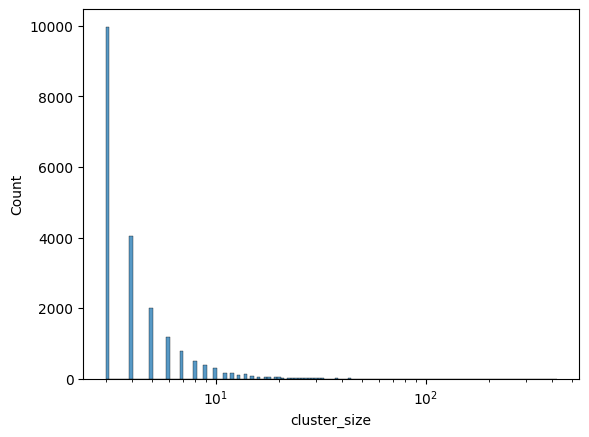

In [21]:
sns.histplot(df[['cluster_id', 'cluster_size']].drop_duplicates().cluster_size, log_scale=True)


In [22]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

def plot_volcano(df, pval_threshold=0.05, fold_threshold=0, sample_name="", ax=None):
    df = df.copy()
    df['log10_pval'] = -np.log10(df['enrichment_pvalue_zbinom'] + 1e-10)
    df['significant'] = (df['enrichment_fdr_zbinom'] < pval_threshold) & (df['log_fold_change'] > fold_threshold)

    # Определение цветов
    main_color = '#2171b5'   # синий для значимых
    base_color = '#ffffcc'   # жёлтый для остальных

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    # Рисуем все точки (не vdjdb)
    sns.scatterplot(
        data=df[~df['vdjdb']],
        x='log_fold_change',
        y='log10_pval',
        hue='significant',
        palette={True: main_color, False: base_color},
        edgecolor='black',
        linewidth=0.3,
        ax=ax,
        # s=70,
        alpha=0.85,
    )

    # Поверх них рисуем vdjdb точки красными квадратами
    sns.scatterplot(
        data=df[df['vdjdb']],
        x='log_fold_change',
        y='log10_pval',
        marker='s',
        color='red',
        edgecolor='black',
        linewidth=0.4,
        ax=ax,
        # s=70,
        alpha=1.0,
        label='as_pattern'
    )

    # Линии порогов
    bonferroni_thresh = max(df[df['enrichment_fdr_zbinom'] < pval_threshold]['enrichment_pvalue_zbinom'], default=1.0)
    log10_bonferroni = -np.log10(bonferroni_thresh)
    ax.axvline(fold_threshold, ls='--', color='black')
    ax.axhline(-np.log10(pval_threshold), ls='--', color='black')
    ax.axhline(log10_bonferroni, ls=':', color='blue')

    # Подписи
    num_significant = df['significant'].sum()
    ax.set_xlabel('log2(Fold Enrichment)')
    ax.set_ylabel('-log10(p-value)')
    ax.set_title(f'{sample_name}: # clusters (fdr < {pval_threshold}): {num_significant}')
    ax.legend()


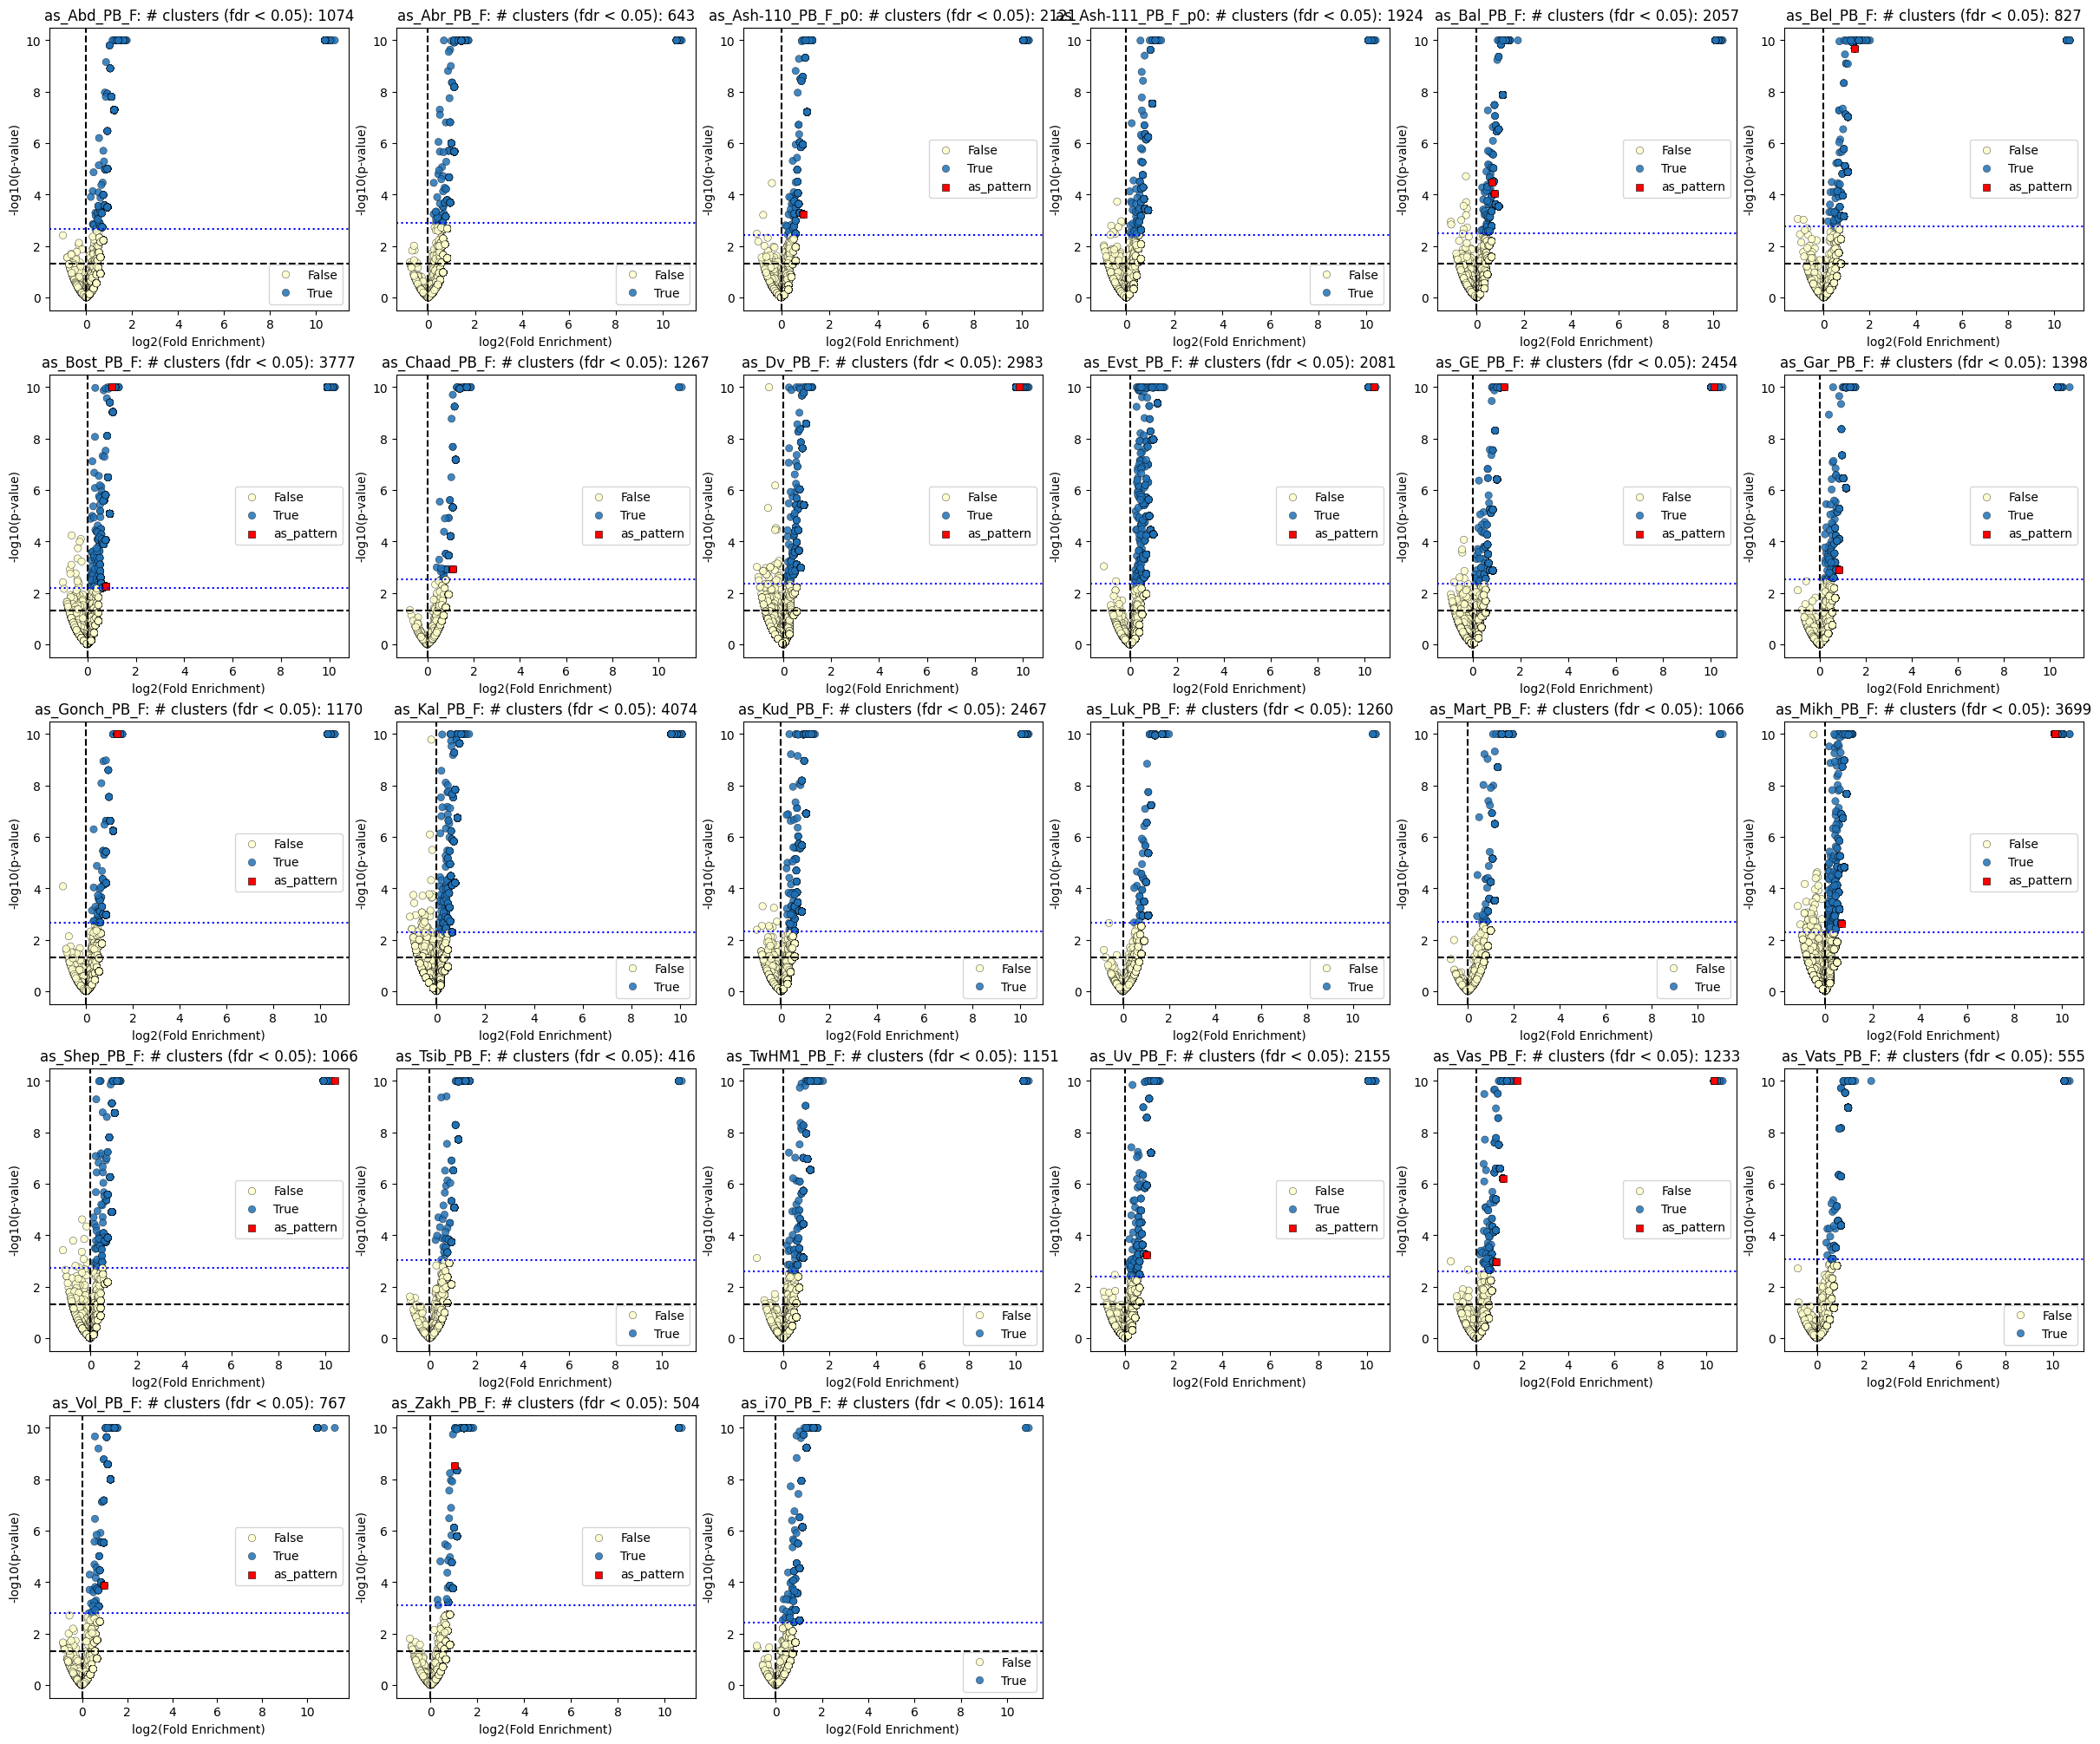

In [23]:
import matplotlib.pyplot as plt

ncols = 6
nrows = 5
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 4, nrows * 4), constrained_layout=True)

for i, s in enumerate(samples):
    row, col = divmod(i, ncols)
    ax = axes[row, col]
    s_res = sample_to_data[s]
    plot_volcano(s_res[0], ax=ax, fold_threshold=0, sample_name=s)

# Удалим лишние пустые сабплоты (если samples < 27)
for j in range(len(samples), ncols * nrows):
    fig.delaxes(axes[j // ncols, j % ncols])
plt.savefig('as_volcanos.png', dpi=300)
plt.show()

In [24]:
all_info = []
for s in samples:
    s_res = sample_to_data[s][0]
    res_df = s_res[['cluster_id', 'vdjdb', 'enrichment_fdr_zbinom', 'log_fold_change']]
    res_df = res_df[(res_df.enrichment_fdr_zbinom < 0.05) & (res_df.log_fold_change > 0)]
    res_df['sample'] = s
    all_info.append(res_df)

In [25]:
joint = pd.concat(all_info)

In [26]:
joint

,cluster_id,vdjdb,enrichment_fdr_zbinom,log_fold_change,sample
8,8,False,0.000000e+00,10.400674,as_Abd_PB_F
10,10,False,8.686075e-09,1.020463,as_Abd_PB_F
11,11,False,0.000000e+00,10.400674,as_Abd_PB_F
12,12,False,1.961957e-06,1.224583,as_Abd_PB_F
13,13,False,0.000000e+00,10.525613,as_Abd_PB_F
...,...,...,...,...,...
20773,20773,False,4.048891e-02,1.027576,as_i70_PB_F
20785,20785,False,4.048891e-02,1.027576,as_i70_PB_F
20789,20789,False,4.048891e-02,1.027576,as_i70_PB_F
20790,20790,False,4.048891e-02,1.027576,as_i70_PB_F


In [27]:
joint = joint.rename(columns={'log_fold_change': 'fold_enrichment', 'enrichment_fdr_zbinom': 'pvalue'})

In [28]:
joint[joint.vdjdb].sort_values(by='sample')

,cluster_id,vdjdb,pvalue,fold_enrichment,sample
4765,4765,True,7.510953e-03,0.891663,as_Ash-110_PB_F_p0
505,505,True,3.866777e-03,0.751255,as_Bal_PB_F
692,692,True,1.608984e-03,0.626316,as_Bal_PB_F
991,991,True,6.215881e-09,1.358001,as_Bel_PB_F
423,423,True,4.210667e-12,0.996437,as_Bost_PB_F
5166,5166,True,4.566328e-02,0.753399,as_Bost_PB_F
5440,5440,True,4.566328e-02,0.753399,as_Bost_PB_F
11569,11569,True,2.050295e-02,1.093133,as_Chaad_PB_F
5305,5305,True,0.000000e+00,9.856962,as_Dv_PB_F
43,43,True,0.000000e+00,10.401299,as_Evst_PB_F


In [29]:
joint[joint['sample'] == 'as_Abd_PB_F'].cluster_id

8            8
10          10
11          11
12          12
13          13
         ...  
22888    22888
22896    22896
22964    22964
22965    22965
23061    23061
Name: cluster_id, Length: 1074, dtype: int64

In [30]:
all_clonotypes_enriched = []
for patient in samples:
    t = get_clonotypes(patient).drop(columns=['enrichment_pvalue_zbinom'])
    # t = t[t.source == 'sample']
    t = t[t.cluster_id.isin(joint[joint['sample'] == patient].cluster_id)]
    t['cluster_id'] = patient + '_c' + t.cluster_id.astype(str)
    t['sample_name'] = patient
    all_clonotypes_enriched.append(t)

In [31]:
data = pd.concat(all_clonotypes_enriched)#.drop(columns=['source'])
data

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name
0,s_29,as_Abd_PB_F_c8,CASSPPSGSYEQYF,TRBV7-9*01,TRBJ2-7*01,sample,as_Abd_PB_F
1,s_34,as_Abd_PB_F_c10,CASSLGSYNEQFF,TRBV7-7*01,TRBJ2-1*01,sample,as_Abd_PB_F
2,s_39,as_Abd_PB_F_c11,CASSQGTSLETQYF,TRBV5-1*01,TRBJ2-5*01,sample,as_Abd_PB_F
3,s_43,as_Abd_PB_F_c12,CASSGTGYTDTQYF,TRBV12-3*01,TRBJ2-3*01,sample,as_Abd_PB_F
4,s_46,as_Abd_PB_F_c13,CASSSGQAYEQYF,TRBV7-8*01,TRBJ2-7*01,sample,as_Abd_PB_F
...,...,...,...,...,...,...,...
7706,b_857137,as_i70_PB_F_c81,CSVKQLDTQYF,TRBV29-1*01,TRBJ2-3*01,background,as_i70_PB_F
7707,b_857159,as_i70_PB_F_c81,CSVESTDTQYF,TRBV29-1*01,TRBJ2-3*01,background,as_i70_PB_F
7708,b_857189,as_i70_PB_F_c81,CSVKQADTQYF,TRBV29-1*01,TRBJ2-3*01,background,as_i70_PB_F
7709,b_857393,as_i70_PB_F_c3651,CASSDYGYTF,TRBV6-2*01,TRBJ1-2*01,background,as_i70_PB_F


In [32]:
data['vdjdb'] = data.cdr3aa_beta.apply(lambda x: has_vdjdb_match(x) > 0)

In [33]:
data[data.vdjdb][['sample_name']].drop_duplicates()

,sample_name
1464,as_Ash-110_PB_F_p0
164,as_Bal_PB_F
136,as_Bel_PB_F
186,as_Bost_PB_F
3197,as_Chaad_PB_F
1624,as_Dv_PB_F
20,as_Evst_PB_F
25,as_GE_PB_F
845,as_Gar_PB_F
191,as_Gonch_PB_F


In [34]:
found_clonotypes = [ClonotypeAA(cdr3aa=x) for x in data.cdr3aa_beta]
dataset = ClonotypeDataset(found_clonotypes)

In [35]:
import networkx as nx
from collections import defaultdict

In [36]:
df = data

In [37]:
# 1. Построить отображение: cdr3aa → множество cluster_id
cdr3_to_clusters = defaultdict(set)
for _, row in df.iterrows():
    cdr3_to_clusters[row['cdr3aa_beta']].add(row['cluster_id'])

# 2. Построить граф кластеров, связанных общими сиквенсами
G = nx.Graph()
G.add_nodes_from(df['cluster_id'].unique())

for clusters in cdr3_to_clusters.values():
    clusters = list(clusters)
    for i in range(len(clusters)):
        for j in range(i + 1, len(clusters)):
            G.add_edge(clusters[i], clusters[j])

# 3. Компоненты связности → объединённые кластеры
cluster_mapping = {}
for new_id, component in enumerate(nx.connected_components(G)):
    for cluster_id in component:
        cluster_mapping[cluster_id] = new_id

# 4. Применить маппинг
df['merged_cluster_id'] = df['cluster_id'].map(cluster_mapping)

In [38]:
df

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name,vdjdb,merged_cluster_id
0,s_29,as_Abd_PB_F_c8,CASSPPSGSYEQYF,TRBV7-9*01,TRBJ2-7*01,sample,as_Abd_PB_F,False,0
1,s_34,as_Abd_PB_F_c10,CASSLGSYNEQFF,TRBV7-7*01,TRBJ2-1*01,sample,as_Abd_PB_F,False,1
2,s_39,as_Abd_PB_F_c11,CASSQGTSLETQYF,TRBV5-1*01,TRBJ2-5*01,sample,as_Abd_PB_F,False,2
3,s_43,as_Abd_PB_F_c12,CASSGTGYTDTQYF,TRBV12-3*01,TRBJ2-3*01,sample,as_Abd_PB_F,False,3
4,s_46,as_Abd_PB_F_c13,CASSSGQAYEQYF,TRBV7-8*01,TRBJ2-7*01,sample,as_Abd_PB_F,False,4
...,...,...,...,...,...,...,...,...,...
7706,b_857137,as_i70_PB_F_c81,CSVKQLDTQYF,TRBV29-1*01,TRBJ2-3*01,background,as_i70_PB_F,False,134
7707,b_857159,as_i70_PB_F_c81,CSVESTDTQYF,TRBV29-1*01,TRBJ2-3*01,background,as_i70_PB_F,False,134
7708,b_857189,as_i70_PB_F_c81,CSVKQADTQYF,TRBV29-1*01,TRBJ2-3*01,background,as_i70_PB_F,False,134
7709,b_857393,as_i70_PB_F_c3651,CASSDYGYTF,TRBV6-2*01,TRBJ1-2*01,background,as_i70_PB_F,False,19162


In [39]:
df['as_pattern'] = df.cdr3aa_beta.apply(lambda x: has_vdjdb_match(x) > 0)

In [40]:
df

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name,vdjdb,merged_cluster_id,as_pattern
0,s_29,as_Abd_PB_F_c8,CASSPPSGSYEQYF,TRBV7-9*01,TRBJ2-7*01,sample,as_Abd_PB_F,False,0,False
1,s_34,as_Abd_PB_F_c10,CASSLGSYNEQFF,TRBV7-7*01,TRBJ2-1*01,sample,as_Abd_PB_F,False,1,False
2,s_39,as_Abd_PB_F_c11,CASSQGTSLETQYF,TRBV5-1*01,TRBJ2-5*01,sample,as_Abd_PB_F,False,2,False
3,s_43,as_Abd_PB_F_c12,CASSGTGYTDTQYF,TRBV12-3*01,TRBJ2-3*01,sample,as_Abd_PB_F,False,3,False
4,s_46,as_Abd_PB_F_c13,CASSSGQAYEQYF,TRBV7-8*01,TRBJ2-7*01,sample,as_Abd_PB_F,False,4,False
...,...,...,...,...,...,...,...,...,...,...
7706,b_857137,as_i70_PB_F_c81,CSVKQLDTQYF,TRBV29-1*01,TRBJ2-3*01,background,as_i70_PB_F,False,134,False
7707,b_857159,as_i70_PB_F_c81,CSVESTDTQYF,TRBV29-1*01,TRBJ2-3*01,background,as_i70_PB_F,False,134,False
7708,b_857189,as_i70_PB_F_c81,CSVKQADTQYF,TRBV29-1*01,TRBJ2-3*01,background,as_i70_PB_F,False,134,False
7709,b_857393,as_i70_PB_F_c3651,CASSDYGYTF,TRBV6-2*01,TRBJ1-2*01,background,as_i70_PB_F,False,19162,False


In [41]:
df.cluster_id.value_counts()

cluster_id
as_Bost_PB_F_c124          675
as_GE_PB_F_c144            639
as_Ash-111_PB_F_p0_c378    587
as_Uv_PB_F_c69             557
as_Vas_PB_F_c119           526
                          ... 
as_i70_PB_F_c3599            3
as_Abd_PB_F_c12              3
as_Abd_PB_F_c22964           3
as_i70_PB_F_c3417            3
as_i70_PB_F_c3421            3
Name: count, Length: 45803, dtype: int64

In [42]:
df.merged_cluster_id.value_counts()

merged_cluster_id
134      8130
26       5159
132      4100
25       3472
1444     3202
         ... 
24499       3
24500       3
24501       3
24502       3
24503       3
Name: count, Length: 24518, dtype: int64

In [43]:
df.groupby("merged_cluster_id").nunique()[["sample_name", 'as_pattern']]
# test['as_pattern'].value_counts()

,sample_name,as_pattern
merged_cluster_id,,
0,2,1
1,11,1
2,1,1
3,1,1
4,27,1
...,...,...
24513,1,1
24514,1,1
24515,1,1


In [44]:
source_counts = df.pivot_table(index='merged_cluster_id', columns='source', 
                               values='clone_id', aggfunc='count', fill_value=0).reset_index()
source_counts

source,merged_cluster_id,background,sample
0,0,1,5
1,1,42,67
2,2,0,3
3,3,1,2
4,4,1202,1165
...,...,...,...
24513,24513,2,1
24514,24514,4,2
24515,24515,2,1
24516,24516,2,1


In [45]:
df.groupby('merged_cluster_id').agg({
    'sample_name': 'nunique',          # количество уникальных значений
    'as_pattern': 'any'               # хотя бы одно True
})

,sample_name,as_pattern
merged_cluster_id,,
0,2,False
1,11,False
2,1,False
3,1,False
4,27,False
...,...,...
24513,1,False
24514,1,False
24515,1,False


In [46]:
from mir.basic.pgen import OlgaModel

In [47]:
olga = OlgaModel()

In [48]:
olga.compute_pgen_cdr3aa('CASSPPSGSYEQYF')

2.0855611266511384e-07

In [49]:
df['pgen'] = df.cdr3aa_beta.apply(olga.compute_pgen_cdr3aa)

In [50]:
df

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name,vdjdb,merged_cluster_id,as_pattern,pgen
0,s_29,as_Abd_PB_F_c8,CASSPPSGSYEQYF,TRBV7-9*01,TRBJ2-7*01,sample,as_Abd_PB_F,False,0,False,2.085561e-07
1,s_34,as_Abd_PB_F_c10,CASSLGSYNEQFF,TRBV7-7*01,TRBJ2-1*01,sample,as_Abd_PB_F,False,1,False,1.071792e-06
2,s_39,as_Abd_PB_F_c11,CASSQGTSLETQYF,TRBV5-1*01,TRBJ2-5*01,sample,as_Abd_PB_F,False,2,False,9.615423e-09
3,s_43,as_Abd_PB_F_c12,CASSGTGYTDTQYF,TRBV12-3*01,TRBJ2-3*01,sample,as_Abd_PB_F,False,3,False,4.903500e-08
4,s_46,as_Abd_PB_F_c13,CASSSGQAYEQYF,TRBV7-8*01,TRBJ2-7*01,sample,as_Abd_PB_F,False,4,False,3.748548e-07
...,...,...,...,...,...,...,...,...,...,...,...
7706,b_857137,as_i70_PB_F_c81,CSVKQLDTQYF,TRBV29-1*01,TRBJ2-3*01,background,as_i70_PB_F,False,134,False,1.672432e-10
7707,b_857159,as_i70_PB_F_c81,CSVESTDTQYF,TRBV29-1*01,TRBJ2-3*01,background,as_i70_PB_F,False,134,False,2.632871e-08
7708,b_857189,as_i70_PB_F_c81,CSVKQADTQYF,TRBV29-1*01,TRBJ2-3*01,background,as_i70_PB_F,False,134,False,8.251335e-10
7709,b_857393,as_i70_PB_F_c3651,CASSDYGYTF,TRBV6-2*01,TRBJ1-2*01,background,as_i70_PB_F,False,19162,False,9.115608e-07


In [51]:
# Считаем общий размер кластера
cluster_sizes = df.groupby("merged_cluster_id").size().reset_index(name="cluster_size")

# Считаем количество пациентов и наличие паттерна
n_patients = df.groupby('merged_cluster_id').agg({
    'sample_name': 'nunique',
    'as_pattern': 'any', 
    'pgen': 'mean'
}).reset_index().rename(columns={'sample_name': "n_patients"})

# Считаем количество элементов из каждого источника (source)
source_counts = df.pivot_table(index='merged_cluster_id', columns='source', 
                               values='clone_id', aggfunc='count', fill_value=0).reset_index()

# Объединяем таблицы
summary = cluster_sizes.merge(n_patients, on="merged_cluster_id")
summary = summary.merge(source_counts, on="merged_cluster_id")

# Считаем доли элементов из каждого источника
summary['sample_fraction'] = summary.get('sample', 0) / summary['cluster_size']
summary['background_fraction'] = summary.get('background', 0) / summary['cluster_size']

# Сортировка
summary = summary.sort_values(by=["n_patients", "cluster_size"], ascending=False)


In [52]:
summary

,merged_cluster_id,cluster_size,n_patients,as_pattern,pgen,background,sample,sample_fraction,background_fraction
26,26,5159,27,False,4.896969e-07,3046,2113,0.409575,0.590425
25,25,3472,27,False,1.620960e-07,1876,1596,0.459677,0.540323
94,94,2477,27,False,2.395123e-07,1221,1256,0.507065,0.492935
4,4,2367,27,False,4.167238e-07,1202,1165,0.492184,0.507816
30,30,1392,27,False,3.577583e-07,724,668,0.479885,0.520115
...,...,...,...,...,...,...,...,...,...
24511,24511,3,1,False,1.806763e-07,2,1,0.333333,0.666667
24513,24513,3,1,False,1.172537e-07,2,1,0.333333,0.666667
24515,24515,3,1,False,6.422961e-10,2,1,0.333333,0.666667
24516,24516,3,1,False,4.641977e-10,2,1,0.333333,0.666667


In [53]:
#summary[summary.n_patients > 3].sort_values(by=['pgen',  'sample_fraction', 'n_patients'], ascending=True).head(50).reset_index(drop=True)

In [56]:
summary.sort_values(by='cluster_size', ascending=False).head(10)

,merged_cluster_id,cluster_size,n_patients,as_pattern,pgen,background,sample,sample_fraction,background_fraction
134,134,8130,18,False,3.420985e-08,6145,1985,0.244157,0.755843
26,26,5159,27,False,4.896969e-07,3046,2113,0.409575,0.590425
132,132,4100,17,False,2.980145e-08,2674,1426,0.347805,0.652195
25,25,3472,27,False,1.620960e-07,1876,1596,0.459677,0.540323
1444,1444,3202,18,False,7.755854e-08,2135,1067,0.333229,0.666771
32,32,2922,26,False,6.586521e-07,1727,1195,0.408966,0.591034
94,94,2477,27,False,2.395123e-07,1221,1256,0.507065,0.492935
4,4,2367,27,False,4.167238e-07,1202,1165,0.492184,0.507816
115,115,2278,26,False,1.461185e-06,1308,970,0.425812,0.574188
3008,3008,2151,12,False,4.978250e-08,1373,778,0.361692,0.638308


In [57]:
summary[summary.as_pattern]

,merged_cluster_id,cluster_size,n_patients,as_pattern,pgen,background,sample,sample_fraction,background_fraction
4514,4514,106,14,True,9.186005e-09,31,75,0.707547,0.292453
2208,2208,20,5,True,9.003584e-08,9,11,0.550000,0.450000
12432,12432,7,2,True,3.462544e-09,0,7,1.000000,0.000000
19219,19219,4,1,True,7.005896e-09,1,3,0.750000,0.250000
19385,19385,3,1,True,4.541401e-08,0,3,1.000000,0.000000


In [58]:
import logomaker

In [59]:
def plot_logo(clonotypes):
    mat_df = logomaker.alignment_to_matrix(clonotypes)
    logomaker.Logo(mat_df, color_scheme='skylign_protein', ax=None)

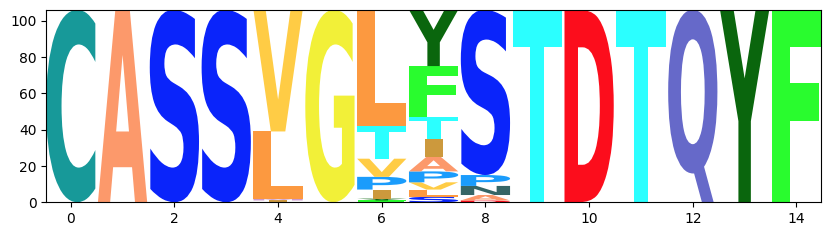

In [125]:
mat_df = logomaker.alignment_to_matrix(df[df.merged_cluster_id == 4514].cdr3aa_beta)
logomaker.Logo(mat_df, color_scheme='skylign_protein', ax=None)
# df[df.merged_cluster_id == 2309]

In [66]:
from mir.common.parser import *
from mir.common.repertoire import Repertoire
from mir.common.repertoire_dataset import RepertoireDataset
from mir.common.clonotype_dataset import ClonotypeDataset
from mir.basic.segment_usage import *
from mir.basic.sampling import RepertoireSampling
from mir.biomarkers.fisher_biomarkers_detector import FisherBiomarkersDetector
from mir.comparative.pair_matcher import PairMatcher
import time
from pympler.asizeof import asizeof

/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [67]:
metadata = metadata.reset_index(drop=True)

In [68]:
t0 = time.time()
dataset = RepertoireDataset.load(parser=AIRRParser(), 
                                 metadata=metadata,
                                 threads=16,
                                 paths=[f'/projects/immunestatus/rheum/airr_format/{r}.tsv' for r in samples], 
                                 gene='TRB')
print(time.time() - t0)

loading Repertoire objects: 100%|██████████| 27/27 [00:42<00:00,  1.59s/it]

43.322362661361694


In [69]:
dataset.pair_matcher = PairMatcher(clonotype_representation_method='cdr3aa,vj',
                                   clonotype_comparison_method='full',)

In [70]:
dataset.mismatch_max = 0

In [71]:
from mir.comparative.pair_matcher import ClonotypeRepresentation

In [72]:
df

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name,vdjdb,merged_cluster_id,as_pattern,pgen
0,s_29,as_Abd_PB_F_c8,CASSPPSGSYEQYF,TRBV7-9*01,TRBJ2-7*01,sample,as_Abd_PB_F,False,0,False,2.085561e-07
1,s_34,as_Abd_PB_F_c10,CASSLGSYNEQFF,TRBV7-7*01,TRBJ2-1*01,sample,as_Abd_PB_F,False,1,False,1.071792e-06
2,s_39,as_Abd_PB_F_c11,CASSQGTSLETQYF,TRBV5-1*01,TRBJ2-5*01,sample,as_Abd_PB_F,False,2,False,9.615423e-09
3,s_43,as_Abd_PB_F_c12,CASSGTGYTDTQYF,TRBV12-3*01,TRBJ2-3*01,sample,as_Abd_PB_F,False,3,False,4.903500e-08
4,s_46,as_Abd_PB_F_c13,CASSSGQAYEQYF,TRBV7-8*01,TRBJ2-7*01,sample,as_Abd_PB_F,False,4,False,3.748548e-07
...,...,...,...,...,...,...,...,...,...,...,...
7706,b_857137,as_i70_PB_F_c81,CSVKQLDTQYF,TRBV29-1*01,TRBJ2-3*01,background,as_i70_PB_F,False,134,False,1.672432e-10
7707,b_857159,as_i70_PB_F_c81,CSVESTDTQYF,TRBV29-1*01,TRBJ2-3*01,background,as_i70_PB_F,False,134,False,2.632871e-08
7708,b_857189,as_i70_PB_F_c81,CSVKQADTQYF,TRBV29-1*01,TRBJ2-3*01,background,as_i70_PB_F,False,134,False,8.251335e-10
7709,b_857393,as_i70_PB_F_c3651,CASSDYGYTF,TRBV6-2*01,TRBJ1-2*01,background,as_i70_PB_F,False,19162,False,9.115608e-07


In [73]:
public_clonotypes = df.apply(lambda x: ClonotypeRepresentation(cdr3aa=x.cdr3aa_beta, v=x.v_beta, j=x.j_beta), axis=1)

In [74]:
df

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name,vdjdb,merged_cluster_id,as_pattern,pgen
0,s_29,as_Abd_PB_F_c8,CASSPPSGSYEQYF,TRBV7-9*01,TRBJ2-7*01,sample,as_Abd_PB_F,False,0,False,2.085561e-07
1,s_34,as_Abd_PB_F_c10,CASSLGSYNEQFF,TRBV7-7*01,TRBJ2-1*01,sample,as_Abd_PB_F,False,1,False,1.071792e-06
2,s_39,as_Abd_PB_F_c11,CASSQGTSLETQYF,TRBV5-1*01,TRBJ2-5*01,sample,as_Abd_PB_F,False,2,False,9.615423e-09
3,s_43,as_Abd_PB_F_c12,CASSGTGYTDTQYF,TRBV12-3*01,TRBJ2-3*01,sample,as_Abd_PB_F,False,3,False,4.903500e-08
4,s_46,as_Abd_PB_F_c13,CASSSGQAYEQYF,TRBV7-8*01,TRBJ2-7*01,sample,as_Abd_PB_F,False,4,False,3.748548e-07
...,...,...,...,...,...,...,...,...,...,...,...
7706,b_857137,as_i70_PB_F_c81,CSVKQLDTQYF,TRBV29-1*01,TRBJ2-3*01,background,as_i70_PB_F,False,134,False,1.672432e-10
7707,b_857159,as_i70_PB_F_c81,CSVESTDTQYF,TRBV29-1*01,TRBJ2-3*01,background,as_i70_PB_F,False,134,False,2.632871e-08
7708,b_857189,as_i70_PB_F_c81,CSVKQADTQYF,TRBV29-1*01,TRBJ2-3*01,background,as_i70_PB_F,False,134,False,8.251335e-10
7709,b_857393,as_i70_PB_F_c3651,CASSDYGYTF,TRBV6-2*01,TRBJ1-2*01,background,as_i70_PB_F,False,19162,False,9.115608e-07


In [75]:
public_clonotypes= public_clonotypes.reset_index(drop=True)

In [76]:
public_clonotypes = list(public_clonotypes)

In [77]:
public_clonotypes[10]

ClonotypeRepresentation(cdr3aa='CASSPPSGSYEQYF', v='TRBV7-9*01', j='TRBJ2-7*01', cdr3nt=None)

In [78]:
public_clono_set = set(public_clonotypes)

In [79]:
len(public_clono_set)

165676

In [80]:
list(public_clono_set)[10]

ClonotypeRepresentation(cdr3aa='CSARATGRRTDTQYF', v='TRBV20-1*01', j='TRBJ2-3*01', cdr3nt=None)

In [81]:
ClonotypeRepresentation(cdr3aa = dataset[0][0].cdr3aa, v=dataset[0][0].v.id, j = dataset[0][0].j.id)

ClonotypeRepresentation(cdr3aa='CSASSETGELFF', v='TRBV20-1*01', j='TRBJ2-2*01', cdr3nt=None)

In [82]:
ClonotypeRepresentation(cdr3aa='CSAKDRGRVTEAFF', v='TRBV20-1*01', j='TRBJ1-1*01') in public_clonotypes

True

In [83]:
clonotype_idx_to_patients = defaultdict(set)
for patient in dataset:
    patient_clono_repr_set = set([ClonotypeRepresentation(cdr3aa=x.cdr3aa, v=x.v.id, j=x.j.id) for x in patient.clonotypes])
    for i, clonotype_repr in enumerate(public_clonotypes):
        if clonotype_repr in patient_clono_repr_set:
            clonotype_idx_to_patients[i].add(patient)

In [84]:
metadata_h =metadata_h.reset_index(drop=True)

In [85]:
metadata_h

,donor_id,disease_status,b27,proj,sample_type,time_point,sample_name,fraction
0,Koc,hd,pos,GCSF,PBMC,normal blood,Koc,NaN
1,Make,hd,pos,ch45,CD45RAdepleted PBMC,after G-CSFstim,Make,NaN
2,p144852,hd,pos,ch45-2,PBMC,after G-CSFstim,p144852,NaN
3,p1004,hd,pos,child_Leu,PBMC,after G-CSFstim,p1004,NaN
4,p112635,hd,pos,ch45-2,PBMC,after G-CSFstim,p112635,NaN
5,p434,hd,neg,child_Leu,PBMC,after G-CSFstim,p434,NaN
6,p556,hd,neg,child_Leu,PBMC,after G-CSFstim,p556,NaN
7,p744,hd,neg,child_Leu,PBMC,after G-CSFstim,p744,NaN
8,p754,hd,neg,child_Leu,PBMC,after G-CSFstim,p754,NaN
9,p1005,hd,neg,child_Leu,PBMC,after G-CSFstim,p1005,NaN


In [86]:
#metadata_h = metadata_h[metadata_h.b27 == 'pos'].reset_index(drop=True)

In [87]:
t0 = time.time()
dataset_h = RepertoireDataset.load(parser=AIRRParser(), 
                                 metadata=metadata_h,
                                 threads=16,
                                 paths=[f'/projects/immunestatus/rheum/airr_format/{r}.tsv' for r in metadata_h.sample_name], 
                                 gene='TRB')
print(time.time() - t0)

loading Repertoire objects: 100%|██████████| 33/33 [01:01<00:00,  1.86s/it]


62.623985052108765


In [88]:
clonotype_idx_to_patients_h = defaultdict(set)
for patient in dataset_h:
    patient_clono_repr_set = set([ClonotypeRepresentation(cdr3aa=x.cdr3aa, v=x.v.id, j=x.j.id) for x in patient.clonotypes])
    for i, clonotype_repr in enumerate(public_clonotypes):
        if clonotype_repr in patient_clono_repr_set:
            clonotype_idx_to_patients_h[i].add(patient)

In [89]:
df = df.reset_index(drop=True)

In [90]:
def get_cluster_usage(cluster_idx):
    all_patients = set()
    for clono_idx in df[df.merged_cluster_id == cluster_idx].index:
        all_patients = all_patients.union(clonotype_idx_to_patients[clono_idx])
        # print(clono_idx, [x.metadata.sample_name for x in clonotype_idx_to_patients[clono_idx]])
    return len(all_patients)

In [91]:
def get_cluster_usage_h(cluster_idx, print_info=False):
    all_patients = set()
    for clono_idx in df[df.merged_cluster_id == cluster_idx].index:
        all_patients = all_patients.union(clonotype_idx_to_patients_h[clono_idx])
        if print_info:
            print(clono_idx, [x.metadata.sample_name for x in clonotype_idx_to_patients_h[clono_idx]])
    return len(all_patients)

In [92]:
get_cluster_usage_h(2309, print_info=True)

13510 []
13525 ['p434', 'p1988', 'Azh_0']
13531 ['p2301', 'TA_pre0']
13532 ['p754', 'p1004', 'Azh_0', 'hd_Sass_PB_F', 'p556']
13554 []
18411 ['p1004']
19429 ['hd_LN_PB_F', 'p2301', 'p556', 'p1005']
19954 ['TV_PB_F', 'p1988', 'Azh_0', 'hd_Sass_PB_F', 'hLP']
20422 ['KB_0', 'p1841', 'hd_TwHM2_PB_F', 'p1005', 'p2048']
50976 ['TV_PB_F', 'p1988', 'Azh_0', 'hd_Sass_PB_F', 'hLP']
50983 ['TV_PB_F', 'p744', 'hd_Sass_PB_F']
51333 []
64618 ['hd_LN_PB_F', 'p2301', 'p556', 'p1005']
66009 ['TV_PB_F', 'p1988', 'Azh_0', 'hd_Sass_PB_F', 'hLP']
112971 ['hd_Sass_PB_F']
114619 ['KB_0']
124585 ['hd_Zbot_PB_F']
134995 ['KB_0', 'p1841']
134996 ['KB_0', 'p1841']
140031 ['hd_Zbot_PB_F']
166448 ['KB_0', 'p1841']
166465 []
166631 []
176481 ['hd_Zbot_PB_F']
263013 []
265790 ['p1004']
270022 ['hd_Zbot_PB_F']


19

In [93]:
summary['as_usage'] = summary.merged_cluster_id.apply(get_cluster_usage)

In [94]:
summary['h_usage'] = summary.merged_cluster_id.apply(get_cluster_usage_h)

In [95]:
summary[summary.n_patients > 3].sort_values(by=['sample_fraction', 'n_patients'], ascending=False).head(60).reset_index(drop=True)

,merged_cluster_id,cluster_size,n_patients,as_pattern,pgen,background,sample,sample_fraction,background_fraction,as_usage,h_usage
0,11,25,5,False,4.476789e-09,0,25,1.000000,0.000000,11,12
1,7610,19,4,False,6.746954e-08,0,19,1.000000,0.000000,9,17
2,12317,15,4,False,7.810239e-08,0,15,1.000000,0.000000,10,7
3,2691,14,4,False,3.069090e-08,0,14,1.000000,0.000000,9,13
4,2979,13,4,False,1.288673e-06,0,13,1.000000,0.000000,12,18
5,6120,12,4,False,3.093555e-08,0,12,1.000000,0.000000,10,11
6,15733,14,4,False,6.461598e-08,1,13,0.928571,0.071429,7,6
7,137,82,8,False,4.337910e-08,6,76,0.926829,0.073171,13,21
8,9550,24,4,False,6.963985e-07,2,22,0.916667,0.083333,11,7
9,15654,22,4,False,3.108789e-08,2,20,0.909091,0.090909,8,12


In [96]:
from scipy.stats import fisher_exact

In [97]:
total_as = 27
total_h = 33

# Результаты
p_values = []

# Пробегаем по строкам таблицы
for _, row in summary.iterrows():
    as_used = row["as_usage"]
    h_used = row["h_usage"]
    
    as_not_used = total_as - as_used
    h_not_used = total_h - h_used
    
    # Таблица сопряженности
    contingency = [[as_used, as_not_used],
                   [h_used, h_not_used]]
    
    # Односторонний тест: альтернативная гипотеза — "as > h"
    _, p_value = fisher_exact(contingency)#, alternative='greater')
    p_values.append(p_value)

# Добавим столбец с p-value
summary["fisher_p"] = p_values

In [98]:
summary

,merged_cluster_id,cluster_size,n_patients,as_pattern,pgen,background,sample,sample_fraction,background_fraction,as_usage,h_usage,fisher_p
26,26,5159,27,False,4.896969e-07,3046,2113,0.409575,0.590425,27,33,1.000000
25,25,3472,27,False,1.620960e-07,1876,1596,0.459677,0.540323,27,33,1.000000
94,94,2477,27,False,2.395123e-07,1221,1256,0.507065,0.492935,27,33,1.000000
4,4,2367,27,False,4.167238e-07,1202,1165,0.492184,0.507816,27,33,1.000000
30,30,1392,27,False,3.577583e-07,724,668,0.479885,0.520115,27,33,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
24511,24511,3,1,False,1.806763e-07,2,1,0.333333,0.666667,1,5,0.209248
24513,24513,3,1,False,1.172537e-07,2,1,0.333333,0.666667,2,10,0.048981
24515,24515,3,1,False,6.422961e-10,2,1,0.333333,0.666667,1,2,1.000000
24516,24516,3,1,False,4.641977e-10,2,1,0.333333,0.666667,2,4,0.681231


In [99]:
summary[summary.as_pattern]

,merged_cluster_id,cluster_size,n_patients,as_pattern,pgen,background,sample,sample_fraction,background_fraction,as_usage,h_usage,fisher_p
4514,4514,106,14,True,9.186005e-09,31,75,0.707547,0.292453,21,23,0.565047
2208,2208,20,5,True,9.003584e-08,9,11,0.550000,0.450000,15,21,0.601120
12432,12432,7,2,True,3.462544e-09,0,7,1.000000,0.000000,5,0,0.014782
19219,19219,4,1,True,7.005896e-09,1,3,0.750000,0.250000,1,2,1.000000
19385,19385,3,1,True,4.541401e-08,0,3,1.000000,0.000000,4,9,0.347962


In [100]:
summary[summary.fisher_p < 0.05]

,merged_cluster_id,cluster_size,n_patients,as_pattern,pgen,background,sample,sample_fraction,background_fraction,as_usage,h_usage,fisher_p
745,745,119,14,False,3.507796e-07,62,57,0.478992,0.521008,23,33,0.035990
642,642,103,13,False,3.623640e-07,45,58,0.563107,0.436893,23,33,0.035990
219,219,132,12,False,1.695819e-07,35,97,0.734848,0.265152,20,32,0.017748
2283,2283,130,12,False,7.394543e-08,49,81,0.623077,0.376923,18,30,0.025764
411,411,114,12,False,7.472751e-07,54,60,0.526316,0.473684,23,33,0.035990
...,...,...,...,...,...,...,...,...,...,...,...,...
23962,23962,3,1,False,1.760678e-08,2,1,0.333333,0.666667,1,8,0.033240
24218,24218,3,1,False,1.021284e-08,2,1,0.333333,0.666667,1,8,0.033240
24348,24348,3,1,False,5.853793e-08,2,1,0.333333,0.666667,1,8,0.033240
24489,24489,3,1,False,1.099954e-07,2,1,0.333333,0.666667,1,9,0.017203


In [101]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import KDTree

def plot_volcano(summary,
                 pval_col="fisher_p",
                 as_col="as_usage",
                 h_col="h_usage",
                 pattern_col="as_pattern",
                 label_col="merged_cluster_id",
                 pval_thresh=0.05,
                 label_log2_thresh=1,
                 label_pval_thresh=0.01,
                 merge_distance=0.2):
    """
    Volcano plot с выделением значимых точек, паттернов и агрегацией подписей для близких точек.

    Parameters:
        summary (pd.DataFrame): таблица с колонками `as_usage`, `h_usage`, `fisher_p`, `as_pattern`, `merged_cluster_id`.
        pval_col (str): колонка с p-value.
        as_col (str): колонка с количеством в AS группе.
        h_col (str): колонка с количеством в healthy группе.
        pattern_col (str): булева колонка, выделяющая особый кластер.
        label_col (str): колонка, которую подписывать.
        pval_thresh (float): порог значимости для цвета.
        label_log2_thresh (float): log2 OR выше которого подписываем.
        label_pval_thresh (float): p-value ниже которого подписываем.
        merge_distance (float): расстояние на графике, на котором подписи будут объединяться.
    """
    pseudo = 0.5
    summary = summary.copy()

    summary["log2_or"] = np.log2((summary[as_col] + pseudo) / (summary[h_col] + pseudo))
    summary["neg_log10_p"] = -np.log10(summary[pval_col])

    def categorize(row):
        if row[pattern_col]:
            return "pattern"
        elif row[pval_col] < pval_thresh:
            return "significant"
        else:
            return "nonsignificant"

    summary["volcano_category"] = summary.apply(categorize, axis=1)
    palette = {"nonsignificant": "gray", "significant": "red", "pattern": "blue"}

    plt.figure(figsize=(10, 7))
    sns.scatterplot(
        data=summary,
        x="log2_or",
        y="neg_log10_p",
        hue="volcano_category",
        palette=palette,
        alpha=0.8
    )

    # Подготовка подписей
    labeled = summary[(summary["log2_or"] > label_log2_thresh) &
                      (summary[pval_col] < label_pval_thresh)].copy()

    if not labeled.empty:
        points = np.column_stack((labeled["log2_or"], labeled["neg_log10_p"]))
        tree = KDTree(points)
        visited = set()
        for i, point in enumerate(points):
            if i in visited:
                continue
            idxs = tree.query_ball_point(point, r=merge_distance)
            visited.update(idxs)
            cluster_labels = labeled.iloc[idxs][label_col].astype(str).tolist()
            x, y = point
            plt.text(x, y, ",".join(cluster_labels), fontsize=9, ha='left', va='bottom')

    plt.axhline(-np.log10(pval_thresh), linestyle="--", color="black", label=f"p = {pval_thresh}")
    plt.axvline(0, linestyle="--", color="gray")
    plt.xlabel("log2(AS usage / Healthy usage)")
    plt.ylabel("-log10(p-value)")
    plt.title("Volcano Plot (Fisher's exact test)")
    plt.legend(title="Category")
    plt.tight_layout()
    plt.show()


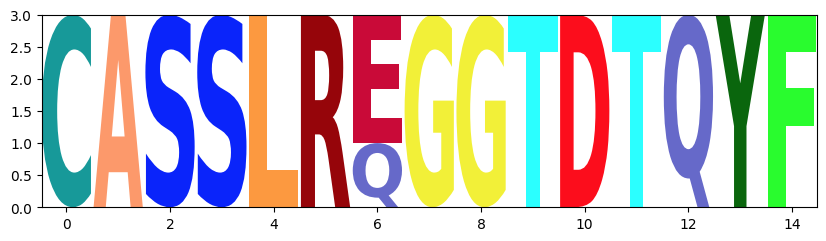

In [102]:
plot_logo(df[df.merged_cluster_id == 3655].cdr3aa_beta)

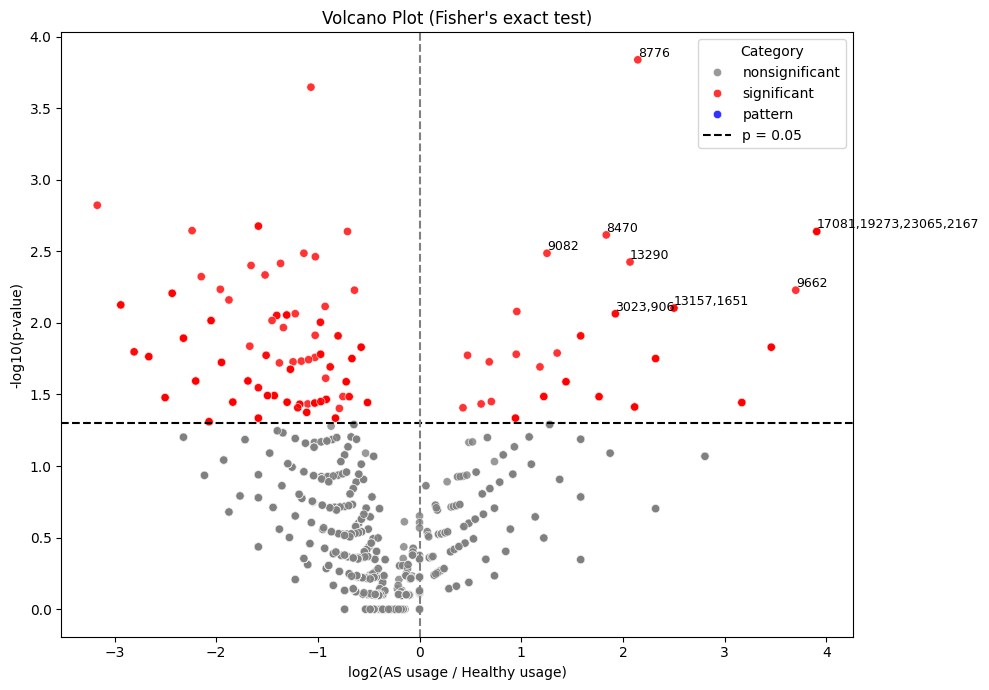

In [103]:
plot_volcano(summary)


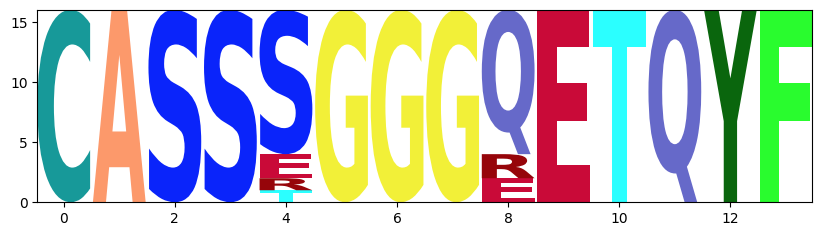

In [104]:
plot_logo(df[df.merged_cluster_id == 6203].cdr3aa_beta)

In [105]:
summary

,merged_cluster_id,cluster_size,n_patients,as_pattern,pgen,background,sample,sample_fraction,background_fraction,as_usage,h_usage,fisher_p
26,26,5159,27,False,4.896969e-07,3046,2113,0.409575,0.590425,27,33,1.000000
25,25,3472,27,False,1.620960e-07,1876,1596,0.459677,0.540323,27,33,1.000000
94,94,2477,27,False,2.395123e-07,1221,1256,0.507065,0.492935,27,33,1.000000
4,4,2367,27,False,4.167238e-07,1202,1165,0.492184,0.507816,27,33,1.000000
30,30,1392,27,False,3.577583e-07,724,668,0.479885,0.520115,27,33,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
24511,24511,3,1,False,1.806763e-07,2,1,0.333333,0.666667,1,5,0.209248
24513,24513,3,1,False,1.172537e-07,2,1,0.333333,0.666667,2,10,0.048981
24515,24515,3,1,False,6.422961e-10,2,1,0.333333,0.666667,1,2,1.000000
24516,24516,3,1,False,4.641977e-10,2,1,0.333333,0.666667,2,4,0.681231


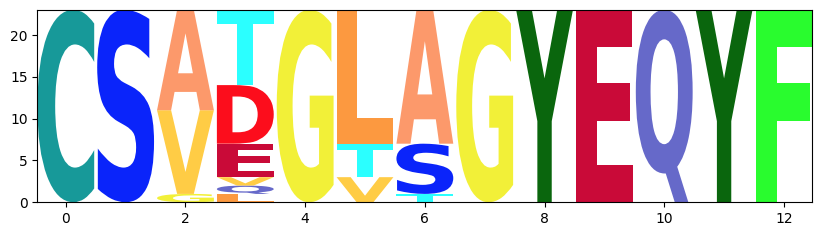

In [106]:
plot_logo(df[df.merged_cluster_id == 2856].cdr3aa_beta)

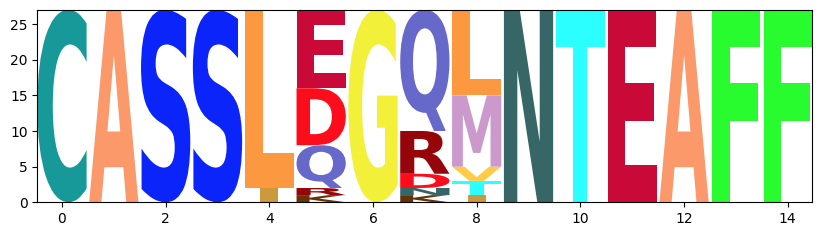

In [107]:
plot_logo(df[df.merged_cluster_id == 2309].cdr3aa_beta)

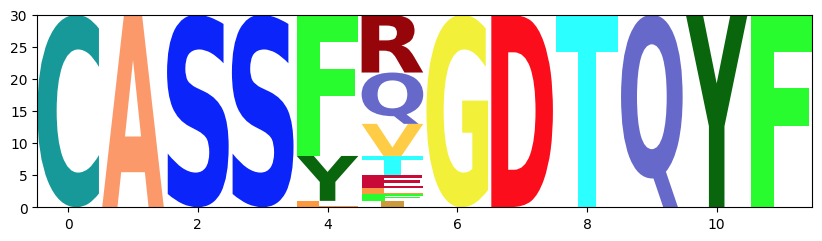

In [108]:
plot_logo(df[df.merged_cluster_id == 870].cdr3aa_beta)

In [109]:
df

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name,vdjdb,merged_cluster_id,as_pattern,pgen
0,s_29,as_Abd_PB_F_c8,CASSPPSGSYEQYF,TRBV7-9*01,TRBJ2-7*01,sample,as_Abd_PB_F,False,0,False,2.085561e-07
1,s_34,as_Abd_PB_F_c10,CASSLGSYNEQFF,TRBV7-7*01,TRBJ2-1*01,sample,as_Abd_PB_F,False,1,False,1.071792e-06
2,s_39,as_Abd_PB_F_c11,CASSQGTSLETQYF,TRBV5-1*01,TRBJ2-5*01,sample,as_Abd_PB_F,False,2,False,9.615423e-09
3,s_43,as_Abd_PB_F_c12,CASSGTGYTDTQYF,TRBV12-3*01,TRBJ2-3*01,sample,as_Abd_PB_F,False,3,False,4.903500e-08
4,s_46,as_Abd_PB_F_c13,CASSSGQAYEQYF,TRBV7-8*01,TRBJ2-7*01,sample,as_Abd_PB_F,False,4,False,3.748548e-07
...,...,...,...,...,...,...,...,...,...,...,...
270416,b_857137,as_i70_PB_F_c81,CSVKQLDTQYF,TRBV29-1*01,TRBJ2-3*01,background,as_i70_PB_F,False,134,False,1.672432e-10
270417,b_857159,as_i70_PB_F_c81,CSVESTDTQYF,TRBV29-1*01,TRBJ2-3*01,background,as_i70_PB_F,False,134,False,2.632871e-08
270418,b_857189,as_i70_PB_F_c81,CSVKQADTQYF,TRBV29-1*01,TRBJ2-3*01,background,as_i70_PB_F,False,134,False,8.251335e-10
270419,b_857393,as_i70_PB_F_c3651,CASSDYGYTF,TRBV6-2*01,TRBJ1-2*01,background,as_i70_PB_F,False,19162,False,9.115608e-07


In [110]:
pgen_df = df.groupby('merged_cluster_id').agg({
    'pgen': 'mean'
}).reset_index()
pgen_df

,merged_cluster_id,pgen
0,0,1.879905e-07
1,1,6.204956e-07
2,2,8.828989e-09
3,3,3.806336e-08
4,4,4.167238e-07
...,...,...
24513,24513,1.172537e-07
24514,24514,1.952171e-08
24515,24515,6.422961e-10
24516,24516,4.641977e-10


In [111]:
pgen_df['log_pgen'] = np.log10(pgen_df.pgen)

In [112]:
pgen_df

,merged_cluster_id,pgen,log_pgen
0,0,1.879905e-07,-6.725864
1,1,6.204956e-07,-6.207261
2,2,8.828989e-09,-8.054089
3,3,3.806336e-08,-7.419493
4,4,4.167238e-07,-6.380152
...,...,...,...
24513,24513,1.172537e-07,-6.930873
24514,24514,1.952171e-08,-7.709482
24515,24515,6.422961e-10,-9.192265
24516,24516,4.641977e-10,-9.333297


In [113]:
summary = summary.merge(pgen_df[['merged_cluster_id', 'log_pgen']])
summary

,merged_cluster_id,cluster_size,n_patients,as_pattern,pgen,background,sample,sample_fraction,background_fraction,as_usage,h_usage,fisher_p,log_pgen
0,26,5159,27,False,4.896969e-07,3046,2113,0.409575,0.590425,27,33,1.000000,-6.310073
1,25,3472,27,False,1.620960e-07,1876,1596,0.459677,0.540323,27,33,1.000000,-6.790228
2,94,2477,27,False,2.395123e-07,1221,1256,0.507065,0.492935,27,33,1.000000,-6.620672
3,4,2367,27,False,4.167238e-07,1202,1165,0.492184,0.507816,27,33,1.000000,-6.380152
4,30,1392,27,False,3.577583e-07,724,668,0.479885,0.520115,27,33,1.000000,-6.446410
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24513,24511,3,1,False,1.806763e-07,2,1,0.333333,0.666667,1,5,0.209248,-6.743099
24514,24513,3,1,False,1.172537e-07,2,1,0.333333,0.666667,2,10,0.048981,-6.930873
24515,24515,3,1,False,6.422961e-10,2,1,0.333333,0.666667,1,2,1.000000,-9.192265
24516,24516,3,1,False,4.641977e-10,2,1,0.333333,0.666667,2,4,0.681231,-9.333297


In [114]:
summary['patient_fc'] = ((summary.as_usage + 1) / 28) / ((summary.h_usage + 1)/ 34)
summary['log_patient_fc'] = np.log10(summary['patient_fc'])

In [115]:
summary['log_cluster_size'] = np.log10(summary['cluster_size'])

In [116]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

def compute_topsis_score(df: pd.DataFrame, metric_types: dict, weight_dict: dict = None):
    df = df.copy()
    metrics = list(metric_types.keys())

    # Шаг 1: Нормализация
    norm_df = df[metrics].copy()
    scaler = MinMaxScaler()
    norm_df[metrics] = scaler.fit_transform(norm_df[metrics])

    # Шаг 2: Учет направлений метрик
    for col, kind in metric_types.items():
        if kind == 'cost':
            norm_df[col] = 1 - norm_df[col]

    # Шаг 3: Применение весов (по умолчанию — равные)
    if weight_dict is None:
        weights = np.ones(len(metrics)) / len(metrics)
    else:
        weights = np.array([weight_dict[m] for m in metrics])
        weights = weights / weights.sum()  # нормализация весов
    weighted = norm_df * weights

    # Шаг 4: Расчет расстояний до идеала и анти-идеала
    ideal = weighted.max()
    anti_ideal = weighted.min()

    d_pos = np.linalg.norm(weighted - ideal, axis=1)
    d_neg = np.linalg.norm(weighted - anti_ideal, axis=1)

    # Шаг 5: Финальный TOPSIS скор
    score = d_neg / (d_pos + d_neg)
    # score = (score - score.min()) / (score.max() - score.min()) 
    df["topsis_score"] = score

    return df.sort_values("topsis_score", ascending=False).reset_index(drop=True)


In [117]:
selected_summary  = summary[summary.log_patient_fc > 0]
selected_summary

,merged_cluster_id,cluster_size,n_patients,as_pattern,pgen,background,sample,sample_fraction,background_fraction,as_usage,h_usage,fisher_p,log_pgen,patient_fc,log_patient_fc,log_cluster_size
42,625,209,19,False,1.962976e-07,126,83,0.397129,0.602871,27,32,1.0,-6.707085,1.030303,0.012965,2.320146
44,75,116,19,False,4.485613e-07,54,62,0.534483,0.465517,27,32,1.0,-6.348178,1.030303,0.012965,2.064458
47,592,539,18,False,7.376131e-08,289,250,0.463822,0.536178,27,32,1.0,-7.132171,1.030303,0.012965,2.731589
48,1050,289,18,False,6.715849e-08,166,123,0.425606,0.574394,27,32,1.0,-7.172899,1.030303,0.012965,2.460898
51,187,258,18,False,5.099013e-08,169,89,0.344961,0.655039,27,32,1.0,-7.292514,1.030303,0.012965,2.411620
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24495,24492,3,1,False,3.386857e-08,2,1,0.333333,0.666667,2,2,1.0,-7.470203,1.214286,0.084321,0.477121
24501,24498,3,1,False,1.064471e-07,2,1,0.333333,0.666667,6,7,1.0,-6.972866,1.062500,0.026329,0.477121
24504,24501,3,1,False,2.225843e-07,1,2,0.666667,0.333333,1,1,1.0,-6.652505,1.214286,0.084321,0.477121
24508,24505,3,1,False,4.914657e-09,2,1,0.333333,0.666667,2,2,1.0,-8.308507,1.214286,0.084321,0.477121


In [118]:
metrics = {
    'n_patients': 'benefit',
    'sample_fraction': 'benefit',
    'log_cluster_size': 'benefit',
    'log_pgen': 'cost',
    'log_patient_fc': 'benefit',
}

custom_weights = {
    'n_patients': 1.25,
    'sample_fraction': 1,
    'log_cluster_size': 2,
    'log_pgen': 1.0,
    'log_patient_fc': 1.5,
}

ranked_df = compute_topsis_score(selected_summary, metrics, weight_dict=custom_weights)
ranked_df.head(20)

,merged_cluster_id,cluster_size,n_patients,as_pattern,pgen,background,sample,sample_fraction,background_fraction,as_usage,h_usage,fisher_p,log_pgen,patient_fc,log_patient_fc,log_cluster_size,topsis_score
0,592,539,18,False,7.376131e-08,289,250,0.463822,0.536178,27,32,1.000000,-7.132171,1.030303,0.012965,2.731589,0.553433
1,4185,724,11,False,3.528776e-09,422,302,0.417127,0.582873,27,32,1.000000,-8.452376,1.030303,0.012965,2.859739,0.536289
2,1050,289,18,False,6.715849e-08,166,123,0.425606,0.574394,27,32,1.000000,-7.172899,1.030303,0.012965,2.460898,0.525347
3,3492,412,14,False,8.378713e-09,245,167,0.405340,0.594660,27,32,1.000000,-8.076823,1.030303,0.012965,2.614897,0.525071
4,1390,217,17,False,4.655598e-07,81,136,0.626728,0.373272,27,32,1.000000,-6.332025,1.030303,0.012965,2.336460,0.517647
5,187,258,18,False,5.099013e-08,169,89,0.344961,0.655039,27,32,1.000000,-7.292514,1.030303,0.012965,2.411620,0.514173
6,625,209,19,False,1.962976e-07,126,83,0.397129,0.602871,27,32,1.000000,-6.707085,1.030303,0.012965,2.320146,0.509931
7,2055,697,7,False,1.887676e-08,399,298,0.427547,0.572453,27,32,1.000000,-7.724073,1.030303,0.012965,2.843233,0.508803
8,333,206,16,False,1.419830e-08,119,87,0.422330,0.577670,27,31,0.496610,-7.847764,1.062500,0.026329,2.313867,0.505321
9,6396,617,7,False,1.489499e-08,370,247,0.400324,0.599676,27,32,1.000000,-7.826960,1.030303,0.012965,2.790285,0.502018


In [119]:
ranked_df[['as_pattern', 'merged_cluster_id', 'cluster_size', 
           'n_patients', 'background', 'sample', 'sample_fraction', 
           'as_usage', 'h_usage', 'log_pgen', 'patient_fc', 'topsis_score']].head(20)

,as_pattern,merged_cluster_id,cluster_size,n_patients,background,sample,sample_fraction,as_usage,h_usage,log_pgen,patient_fc,topsis_score
0,False,592,539,18,289,250,0.463822,27,32,-7.132171,1.030303,0.553433
1,False,4185,724,11,422,302,0.417127,27,32,-8.452376,1.030303,0.536289
2,False,1050,289,18,166,123,0.425606,27,32,-7.172899,1.030303,0.525347
3,False,3492,412,14,245,167,0.405340,27,32,-8.076823,1.030303,0.525071
4,False,1390,217,17,81,136,0.626728,27,32,-6.332025,1.030303,0.517647
5,False,187,258,18,169,89,0.344961,27,32,-7.292514,1.030303,0.514173
6,False,625,209,19,126,83,0.397129,27,32,-6.707085,1.030303,0.509931
7,False,2055,697,7,399,298,0.427547,27,32,-7.724073,1.030303,0.508803
8,False,333,206,16,119,87,0.422330,27,31,-7.847764,1.062500,0.505321
9,False,6396,617,7,370,247,0.400324,27,32,-7.826960,1.030303,0.502018


In [120]:
df[df.merged_cluster_id == 7446]

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name,vdjdb,merged_cluster_id,as_pattern,pgen
50947,s_147830,as_Bost_PB_F_c6341,CASSLGHLNTGELFF,TRBV5-1*01,TRBJ2-2*01,sample,as_Bost_PB_F,False,7446,False,1.365620e-08
50948,s_147834,as_Bost_PB_F_c6341,CASSLGHLNTGELFF,TRBV5-1*01,TRBJ2-2*01,sample,as_Bost_PB_F,False,7446,False,1.365620e-08
51213,s_151326,as_Bost_PB_F_c6341,CASSLGHLDTGELFF,TRBV5-1*01,TRBJ2-2*01,sample,as_Bost_PB_F,False,7446,False,3.729339e-09
64609,b_447651,as_Bost_PB_F_c6341,CASSLGHLNTGELFF,TRBV5-1*01,TRBJ2-2*01,background,as_Bost_PB_F,False,7446,False,1.365620e-08
64611,b_447684,as_Bost_PB_F_c6341,CASSLGHLNTGELFF,TRBV5-1*01,TRBJ2-2*01,background,as_Bost_PB_F,False,7446,False,1.365620e-08


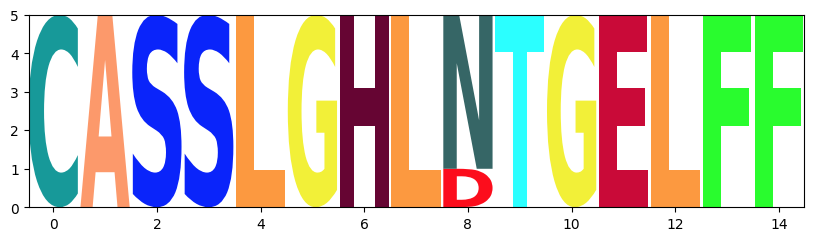

In [121]:
plot_logo(df[df.merged_cluster_id == 7446].cdr3aa_beta)

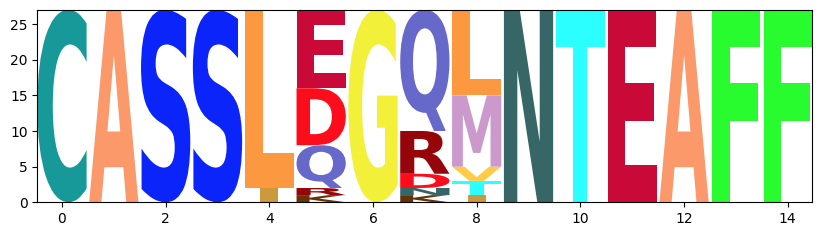

In [122]:
plot_logo(df[df.merged_cluster_id == 2309].cdr3aa_beta)

In [123]:
ranked_df[ranked_df['as_pattern']]

,merged_cluster_id,cluster_size,n_patients,as_pattern,pgen,background,sample,sample_fraction,background_fraction,as_usage,h_usage,fisher_p,log_pgen,patient_fc,log_patient_fc,log_cluster_size,topsis_score
14,4514,106,14,True,9.186005e-09,31,75,0.707547,0.292453,21,23,0.565047,-8.036873,1.113095,0.046532,2.025306,0.488156
32,12432,7,2,True,3.462544e-09,0,7,1.000000,0.000000,5,0,0.014782,-8.460605,7.285714,0.862472,0.845098,0.441312


<Axes: xlabel='log_patient_fc', ylabel='Count'>

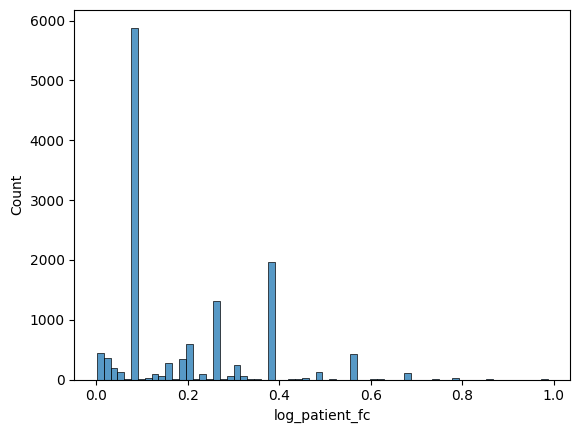

In [124]:
sns.histplot(selected_summary.log_patient_fc)